# 31 · Figura de memoria — imagen real vs contorno Canny estructural (fMRI y EEG)

Reconstruye el contorno Canny que ControlNet recibe como **condición estructural**
en inferencia, y lo compara con la imagen real vista por el sujeto:

```
señal cerebral (fMRI o EEG) -> low_pred (Exp3, rama low-level)
                             -> PCA^-1 -> latente VAE -> decode -> Canny
```

Es el mismo pipeline que `scripts/14_precompute_controlnet_conditions.py`, pero
con `low_pred` (la predicción del decoder a partir de la señal cerebral) en vez
de la reconstrucción PCA de la imagen real: ese es el camino de **caché de
entrenamiento** (`training_condition_source: gt_vae_pca_reconstruction`); aquí
usamos el camino de **inferencia real** (ver `docs/08_ampliacion_multimodal_texto_y_controlnet.md`
y `src/generation/controlnet_condition.py::control_images_from_lowlevel`).

Solo lee checkpoints/configs que ya existen en `outputs/` y `configs/` — no
entrena nada. Requiere haber ejecutado, para cada modalidad, los pasos 00-05
(en particular Exp3, `use_lowlevel: true`, checkpoint en
`outputs/exp03_*/checkpoints/best.pt`) y el precompute de VAE-PCA (paso 04).

Ejecutar con el **python del venv** (`.tfm_fmri_diffusion_3_11`): necesita
`torch`/`diffusers` reales (VAE de Stable Diffusion) y `scikit-image` (Canny).

Las figuras se guardan en `outputs/_memoria/` (misma carpeta que
`scripts/plot_memoria_figures.py`).

In [1]:
# Ejecutar desde la RAIZ DEL REPO para que las rutas relativas (configs/, data/,
# outputs/) se resuelvan igual que en los scripts.
import sys, os
_root = os.getcwd()
while _root != os.path.dirname(_root):
    if os.path.isdir(os.path.join(_root, 'src')) and os.path.isdir(os.path.join(_root, 'configs')):
        break
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
print('project root:', os.getcwd())

from pathlib import Path

import matplotlib.pyplot as plt
import torch

from src.utils import get_device, load_config
from src.data import build_datamodule
from src.data.image_transforms import load_image, tensor_to_pil
from src.evaluation.eval_data import load_subject_matrices
from src.features.precompute_vae_latents import load_vae
from src.generation.controlnet_condition import (build_control_images,
                                                  coarse_images_from_pca)
from src.generation.generate_from_fmri import _forward_full, load_decoder

DEST = Path("outputs/_memoria")
DEST.mkdir(parents=True, exist_ok=True)

project root: c:\Users\xxdia\Documents\TFM\TFM_REPOS_FINALES\tfm_fmri_eeg_diffusion


## Función común a fMRI y EEG

Toma un config de generación (el que ya trae `generation.decoder_checkpoint`,
`features.vae_model` y `generation.controlnet.canny.*`), una imagen concreta
(`split`, `index` posicional dentro de ese split para ese sujeto) y devuelve
las tres imágenes: real, reconstrucción VAE del `low_pred` (coarse) y su
contorno Canny. Reutiliza directamente `coarse_images_from_pca` /
`build_control_images` de `src/generation/controlnet_condition.py` — el mismo
código que usa el script 14 y la generación real — así que el resultado es
exactamente la condición que vería ControlNet en Exp4/5, no una aproximación
hecha ad-hoc para la figura.

In [2]:
def real_image_and_structural_canny(config_path, checkpoint_path=None,
                                     subject=None, split="test", index=0):
    """Imagen real vs. el contorno Canny derivado de low_pred para esa imagen.

    ``señal cerebral -> low_pred (Exp3) -> PCA^-1 -> latente VAE -> decode -> Canny``
    (camino de inferencia; ver docstring del módulo `controlnet_condition`).
    """
    cfg = load_config(config_path)
    device = get_device(cfg.get("runtime.device", "auto"))
    dm = build_datamodule(cfg).prepare()
    subject = subject or dm.subjects[0]

    frame = dm.subject_split_frame(subject, split).reset_index(drop=True)
    row = frame.iloc[index]

    # Misma llamada (mismo orden de filas) que usa load_subject_matrices para
    # construir `mats.fmri`, así que el índice posicional alinea imagen <-> señal.
    mats = load_subject_matrices(cfg, dm, subject, split, want=("fmri",))
    brain_vec = mats.fmri[index:index + 1]

    ckpt = Path(checkpoint_path or cfg.get("generation.decoder_checkpoint"))
    model, meta = load_decoder(cfg, dm, ckpt, device)
    if not meta["use_lowlevel"]:
        raise ValueError(f"{ckpt} no tiene rama estructural (low-level, Exp3).")
    _, low_pred = _forward_full(model, brain_vec, subject, device)

    # fp16 + slicing: mismo ajuste que el precompute real (ver script 14) para
    # que decode() no dispare al VAE a RAM compartida.
    vae = load_vae(cfg, device,
                    dtype=torch.float16 if device.type == "cuda" else None,
                    slicing=True)

    def decode(latents):
        z = torch.as_tensor(latents, dtype=vae.dtype, device=device)
        with torch.no_grad():
            imgs = vae.decode(z / vae.config.scaling_factor).sample
        imgs = (imgs / 2 + 0.5).clamp(0, 1).float().cpu()
        return [tensor_to_pil(i) for i in imgs]

    coarse = coarse_images_from_pca(cfg, decode, subject, low_pred)[0]
    canny = build_control_images(cfg, [coarse], device)[0]
    real = load_image(row["image_path"]).resize(coarse.size)

    del model, vae
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return {"real": real, "coarse": coarse, "canny": canny, "subject": subject,
            "split": split, "image_id": str(row["image_id"])}


def plot_real_vs_canny(result, title, out_path):
    fig, axes = plt.subplots(1, 3, figsize=(11, 4))
    panels = (("real", "Imagen real"),
              ("coarse", "Reconstrucción VAE\n(predicción cerebral, low_pred)"),
              ("canny", "Contorno Canny\n(condición estructural de ControlNet)"))
    for ax, (key, label) in zip(axes, panels):
        ax.imshow(result[key])
        ax.set_title(label, fontsize=10)
        ax.axis("off")
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    print("guardada en:", out_path)

## Figura fMRI (NSD Algonauts 2023)

Usa el config de generación con ControlNet (trae `generation.decoder_checkpoint`
apuntando a `outputs/exp03_fmri_lowlevel_multitask/checkpoints/best.pt`). Cambia
`split`/`index` para elegir otra imagen del sujeto.

01:34:44 | INFO    | datamodule | Loading cached split metadata: data\processed\metadata_subj01.csv


01:34:44 | INFO    | datamodule | Prepared 1 subject(s) ['subj01'] | test_split=official | samples: {'train': np.int64(8857), 'val': np.int64(984), 'test': np.int64(159)} | voxels: {'subj01': 39548}


c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


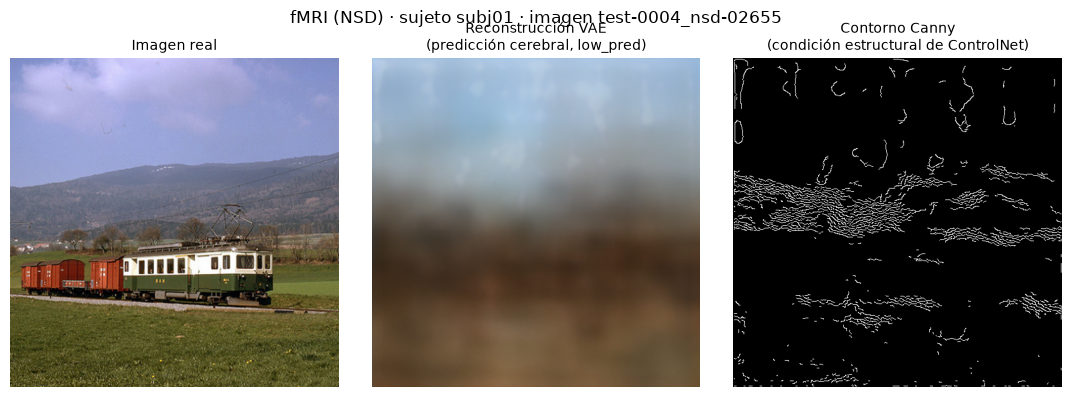

guardada en: outputs\_memoria\fig_real_vs_canny_fmri.png


In [8]:
fmri_result = real_image_and_structural_canny(
    "configs/fMRI/exp04_generation_controlnet_weak.yaml",
    subject=None, split="test", index=3)

plot_real_vs_canny(
    fmri_result,
    f"fMRI (NSD) · sujeto {fmri_result['subject']} · imagen {fmri_result['image_id']}",
    DEST / "fig_real_vs_canny_fmri.png")

## Figura EEG (THINGS-EEG2, 63 canales)

Mismo procedimiento con el decoder EEG de Exp3
(`outputs/exp03_63_eeg_lowlevel_multitask/checkpoints/best.pt`). Si se prefiere
otra variante de preprocesado propio (§05), basta con apuntar `config_path` al
`exp04_raw_<variante>_generation_controlnet_weak.yaml` correspondiente (el
`decoder_checkpoint` de ese config ya apunta al Exp3 entrenado con esa
variante).

01:35:53 | INFO    | eeg_datamodule | Loading cached EEG split metadata: data\processed\metadata_eeg_sub-01_63ch.csv
01:36:00 | INFO    | eeg_datamodule | Prepared 1 EEG subject(s) ['sub-01'] | source=official/63ch | signal={'sub-01': (63, 100)} | normalize=True | agg={'train': 'none', 'val': 'mean', 'test': 'mean'} | images/split: {'train': np.int64(14886), 'val': np.int64(1654), 'test': np.int64(200)}


c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


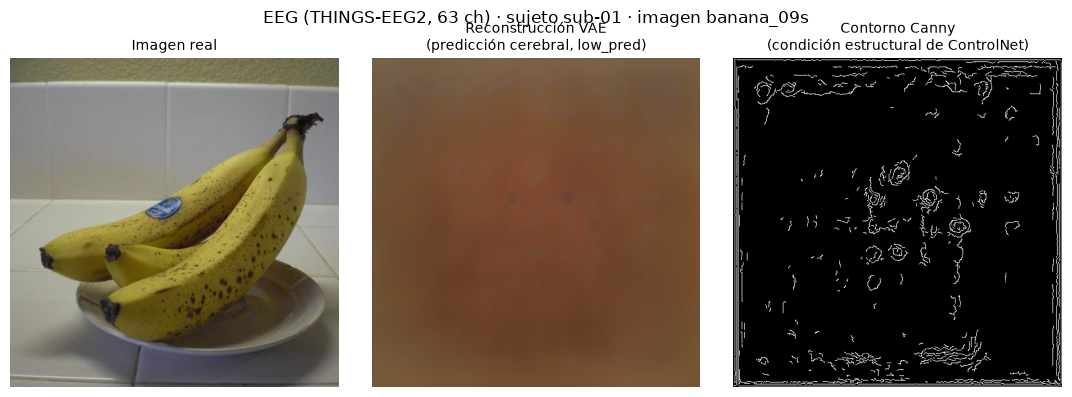

guardada en: outputs\_memoria\fig_real_vs_canny_eeg.png


In [11]:
eeg_result = real_image_and_structural_canny(
    "configs/EEG/exp04_63_generation_controlnet_weak.yaml",
    subject=None, split="test", index=4)

plot_real_vs_canny(
    eeg_result,
    f"EEG (THINGS-EEG2, 63 ch) · sujeto {eeg_result['subject']} · imagen {eeg_result['image_id']}",
    DEST / "fig_real_vs_canny_eeg.png")